# 8. Classification - Random Forest

**Scratch**: Bagging of 100 decision trees with random feature subsampling  
**sklearn**: `RandomForestClassifier` tuned over `n_estimators` × `max_depth`

### Theory

Random Forest reduces the **variance** of a single decision tree by training an ensemble of $T$ trees, each on a **bootstrap sample** of the data, and averaging their predictions.

Two sources of randomness:
1. **Bootstrap sampling** - each tree trains on $n$ rows sampled *with replacement* from the training set (~63% unique rows per tree)
2. **Feature subsampling** - at each split, only $m$ randomly chosen features are considered (standard: $m = \lfloor\sqrt{p}\rfloor$, here $m=3$ from $p=10$)

**Prediction** (classification): majority vote across all $T$ trees:

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\right)$$

**Soft probability** (for ROC-AUC): fraction of trees that predict class 1:

$$\hat{p} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{1}[\hat{y}_t = 1]$$

**Why it outperforms a single tree**: Individual trees are high variance (sensitive to training data). Their errors are partially uncorrelated due to the two randomness sources, so they cancel out in the vote bias stays similar, variance drops.


## 1. Imports, Setup & Shared Utilities

In [1]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score)

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Shared utility: compute all 8 classification metrics ──────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}

# ── Shared utility: append results row to CSV ─────────────────────────────────
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")

# ── Shared utility: plot confusion matrix ─────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")


Utilities loaded.


## 2. Load & Scale Data

In [2]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features ({len(features)}): {features}")
print(f"Class balance (train) — Up: {y_train.mean()*100:.1f}%  Down: {(1-y_train.mean())*100:.1f}%")


X_train: (60260, 10)  |  X_test: (10635, 10)
Features (10): ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']
Class balance (train) — Up: 50.9%  Down: 49.1%


/Users/mihiniboteju/cryptoflow/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/mihiniboteju/cryptoflow/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Random Forest — Scratch

**Parameters**: `n_trees=100`, `max_depth=3`, `max_features=3`, `min_samples_split=20`

Each tree is trained on a **bootstrap sample** (random rows with replacement) and uses only **3 randomly chosen features** at each split. Final prediction = majority vote across all 100 trees.


In [3]:
class RandomForestScratch:
    """
    Random Forest from scratch.

    Two sources of randomness:
      1. Bootstrap sampling  — each tree sees ~63% unique training rows
      2. Feature subsampling — each split considers only max_features random features

    Prediction: majority vote (hard) / mean vote fraction (soft prob for ROC-AUC).
    Uses the optimised DecisionTreeScratch from notebook 7 internally.
    """

    # ── Internal decision tree node ────────────────────────────────────────────
    class _Node:
        def __init__(self, feature_index=None, threshold=None,
                     left=None, right=None, value=None):
            self.feature_index = feature_index
            self.threshold     = threshold
            self.left          = left
            self.right         = right
            self.value         = value
        def is_leaf(self):
            return self.value is not None

    # ── Internal decision tree ─────────────────────────────────────────────────
    class _Tree:
        """
        Lightweight decision tree used inside the forest.
        Identical logic to DecisionTreeScratch but with feature subsampling
        at each split (the key RF ingredient).
        """
        def __init__(self, max_depth, min_samples_split, max_features, rng):
            self.max_depth         = max_depth
            self.min_samples_split = min_samples_split
            self.max_features      = max_features
            self.rng               = rng   # shared numpy random Generator
            self.root              = None

        @staticmethod
        def _gini(y):
            n = len(y)
            if n == 0:
                return 0.0
            counts = np.bincount(y, minlength=2)
            probs  = counts / n
            return 1.0 - np.sum(probs ** 2)

        def _best_split(self, X, y):
            best_gain, best_feat, best_thr = -1.0, None, None
            parent_gini = self._gini(y)
            n = len(y)
            n_features = X.shape[1]

            # ── Feature subsampling: randomly pick max_features features ──
            feat_indices = self.rng.choice(n_features,
                                           size=min(self.max_features, n_features),
                                           replace=False)

            for fi in feat_indices:
                col = X[:, fi]
                unique_vals = np.unique(col)
                if len(unique_vals) <= 1:
                    continue

                # Up to 50 quantile thresholds
                if len(unique_vals) <= 51:
                    thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0
                else:
                    q = np.linspace(0, 100, 52)[1:-1]
                    thresholds = np.unique(np.percentile(col, q))

                for thr in thresholds:
                    lm = col <= thr
                    nl, nr = lm.sum(), n - lm.sum()
                    if nl == 0 or nr == 0:
                        continue
                    gain = (parent_gini
                            - (nl/n) * self._gini(y[lm])
                            - (nr/n) * self._gini(y[~lm]))
                    if gain > best_gain:
                        best_gain, best_feat, best_thr = gain, fi, thr

            return best_feat, best_thr

        def _build(self, X, y, depth):
            Node = RandomForestScratch._Node
            if (depth >= self.max_depth or
                    len(y) < self.min_samples_split or
                    len(np.unique(y)) == 1):
                return Node(value=int(np.bincount(y).argmax()))

            fi, thr = self._best_split(X, y)
            if fi is None:
                return Node(value=int(np.bincount(y).argmax()))

            lm = X[:, fi] <= thr
            return Node(feature_index=fi, threshold=thr,
                        left =self._build(X[lm],  y[lm],  depth+1),
                        right=self._build(X[~lm], y[~lm], depth+1))

        def fit(self, X, y):
            self.root = self._build(X, y, 0)

        def _traverse(self, x, node):
            if node.is_leaf():
                return node.value
            if x[node.feature_index] <= node.threshold:
                return self._traverse(x, node.left)
            return self._traverse(x, node.right)

        def predict(self, X):
            return np.array([self._traverse(x, self.root) for x in X])

    # ── Forest ─────────────────────────────────────────────────────────────────
    def __init__(self, n_trees=100, max_depth=3,
                 max_features=3, min_samples_split=20, random_state=42):
        self.n_trees           = n_trees
        self.max_depth         = max_depth
        self.max_features      = max_features
        self.min_samples_split = min_samples_split
        self.random_state      = random_state
        self.trees_            = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n   = len(y)
        self.trees_ = []

        for i in range(self.n_trees):
            # Bootstrap sample (with replacement)
            idx  = rng.integers(0, n, size=n)
            X_bs, y_bs = X[idx], y[idx]

            tree = self._Tree(
                max_depth         = self.max_depth,
                min_samples_split = self.min_samples_split,
                max_features      = self.max_features,
                rng               = rng
            )
            tree.fit(X_bs, y_bs)
            self.trees_.append(tree)

            if (i + 1) % 20 == 0:
                print(f"  Trees trained: {i+1}/{self.n_trees}")

    def predict_proba(self, X):
        """Fraction of trees voting class 1 — used for ROC-AUC."""
        votes = np.array([t.predict(X) for t in self.trees_])  # (n_trees, n_samples)
        return votes.mean(axis=0)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# ── Train scratch forest ───────────────────────────────────────────────────────
print("Training scratch Random Forest (100 trees, max_depth=3, max_features=3)...")
t0 = time.time()
rf_scratch = RandomForestScratch(n_trees=100, max_depth=3,
                                 max_features=3, min_samples_split=20, random_state=42)
rf_scratch.fit(X_train, y_train)
print(f"Training time: {time.time() - t0:.1f}s")


Training scratch Random Forest (100 trees, max_depth=3, max_features=3)...
  Trees trained: 20/100
  Trees trained: 40/100
  Trees trained: 60/100
  Trees trained: 80/100
  Trees trained: 100/100
Training time: 32.5s



  Random Forest (Scratch)
  Confusion Matrix : TN=2245  FP=3036  FN=2037  TP=3317
  Accuracy         : 0.5230
  Precision        : 0.5221
  Sensitivity      : 0.6195
  Specificity(TNR) : 0.4251
  F1-Score         : 0.5667
  ROC-AUC          : 0.5378


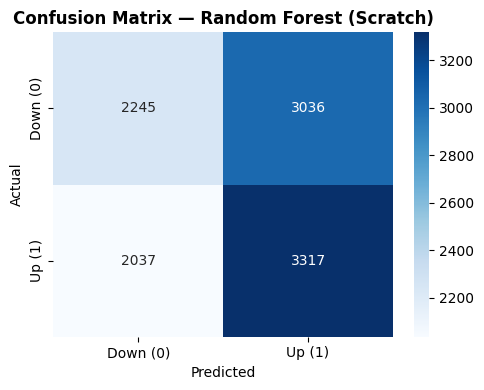

Saved: /Users/mihiniboteju/cryptoflow/plots/cm_rf_scratch.png


In [4]:
# Evaluate scratch forest
y_pred_scratch = rf_scratch.predict(X_test)
y_prob_scratch = rf_scratch.predict_proba(X_test)

metrics_scratch = compute_metrics('Random Forest (Scratch)', y_test, y_pred_scratch, y_prob_scratch)
plot_confusion_matrix(y_test, y_pred_scratch, 'Random Forest (Scratch)',
                      os.path.join(PLOTS_DIR, 'cm_rf_scratch.png'))


## 4. Random Forest — sklearn (Hyperparameter Tuning)

Grid search over:
- `n_estimators` ∈ [50, 100, 200]
- `max_depth` ∈ [3, 5, 10]

All combinations use `max_features=3`, `min_samples_split=20`, `criterion='gini'`.


n_trees    max_depth     Train Acc   Test Acc
----------------------------------------------
50         3                0.5563     0.5247
50         5                0.5666     0.5288
50         10               0.6455     0.5234
100        3                0.5571     0.5254
100        5                0.5672     0.5273
100        10               0.6500     0.5293
200        3                0.5571     0.5252
200        5                0.5675     0.5253
200        10               0.6513     0.5308

Best config: n_estimators=200, max_depth=10  (Test Acc = 0.5308)


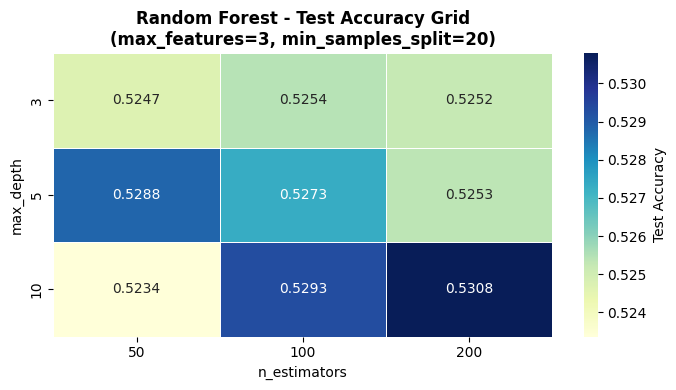

In [ ]:
n_estimators_list = [50, 100, 200]
max_depth_list    = [3, 5, 10]
tune_results      = []

print(f"{'n_trees':<10} {'max_depth':<12} {'Train Acc':>10} {'Test Acc':>10}")
print('-' * 46)

for n_est in n_estimators_list:
    for md in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators     = n_est,
            max_depth        = md,
            max_features     = 3,
            min_samples_split= 20,
            criterion        = 'gini',  # gini 
            random_state     = 42,
            n_jobs           = -1
        )
        rf.fit(X_train, y_train)
        tr_acc = accuracy_score(y_train, rf.predict(X_train))
        te_acc = accuracy_score(y_test,  rf.predict(X_test))
        tune_results.append({'n_est': n_est, 'depth': md,
                             'train_acc': tr_acc, 'test_acc': te_acc, 'model': rf})
        print(f"{n_est:<10} {md:<12} {tr_acc:>10.4f} {te_acc:>10.4f}")

# Best config by test accuracy
best = max(tune_results, key=lambda x: x['test_acc'])
print(f"\nBest config: n_estimators={best['n_est']}, max_depth={best['depth']}"
      f"  (Test Acc = {best['test_acc']:.4f})")

# Heatmap of test accuracy
pivot = pd.DataFrame([{'n_estimators': r['n_est'],
                        'max_depth':    r['depth'],
                        'test_acc':     r['test_acc']} for r in tune_results])
pivot_table = pivot.pivot(index='max_depth', columns='n_estimators', values='test_acc')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Test Accuracy'})
ax.set_title('Random Forest - Test Accuracy Grid\n(max_features=3, min_samples_split=20)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_tuning_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()



  Random Forest sklearn (n=200, depth=10)
  Confusion Matrix : TN=2576  FP=2705  FN=2285  TP=3069
  Accuracy         : 0.5308
  Precision        : 0.5315
  Sensitivity      : 0.5732
  Specificity(TNR) : 0.4878
  F1-Score         : 0.5516
  ROC-AUC          : 0.5405


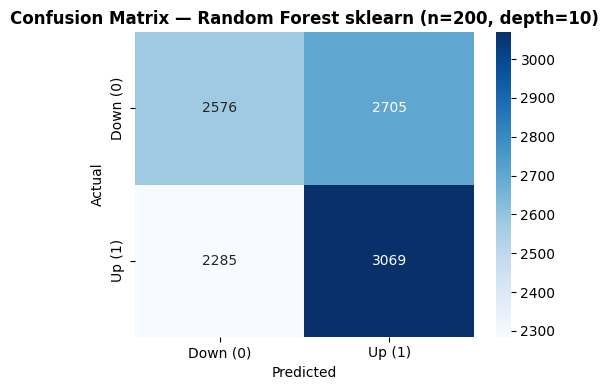

Saved: /Users/mihiniboteju/cryptoflow/plots/cm_rf_sklearn.png

Scratch (100 trees, depth=3) vs sklearn (n=200, depth=10):
  Scratch : 0.5230
  sklearn : 0.5308


In [7]:
# Full evaluation of best sklearn config
rf_sk = best['model']

y_pred_sk = rf_sk.predict(X_test)
y_prob_sk = rf_sk.predict_proba(X_test)[:, 1]

metrics_sk = compute_metrics(
    f"Random Forest sklearn (n={best['n_est']}, depth={best['depth']})",
    y_test, y_pred_sk, y_prob_sk
)
plot_confusion_matrix(
    y_test, y_pred_sk,
    f"Random Forest sklearn (n={best['n_est']}, depth={best['depth']})",
    os.path.join(PLOTS_DIR, 'cm_rf_sklearn.png')
)

print(f"\nScratch (100 trees, depth=3) vs sklearn (n={best['n_est']}, depth={best['depth']}):")
print(f"  Scratch : {metrics_scratch['accuracy']:.4f}")
print(f"  sklearn : {metrics_sk['accuracy']:.4f}")


## 6. ROC Curve & Save Models + Results

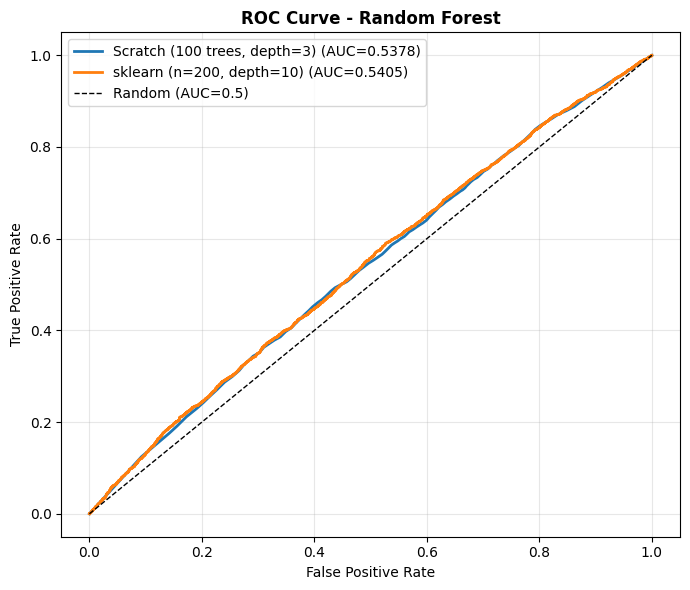

Models saved.
Results saved to /Users/mihiniboteju/cryptoflow/results/classification_results.csv
Results saved to /Users/mihiniboteju/cryptoflow/results/classification_results.csv


In [ ]:
# ROC curve - scratch and sklearn on the same plot
fig, ax = plt.subplots(figsize=(7, 6))
for name, y_prob, color in [
    ('Scratch (100 trees, depth=3)', y_prob_scratch, 'steelblue'),
    (f'sklearn (n={best["n_est"]}, depth={best["depth"]})', y_prob_sk, 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_random_forest.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save models
with open(os.path.join(MODELS_DIR, 'rf_scratch.pkl'), 'wb') as f:
    pickle.dump(rf_scratch, f)
with open(os.path.join(MODELS_DIR, 'rf_sklearn.pkl'), 'wb') as f:
    pickle.dump(rf_sk, f)
print("Models saved.")

# Save results (both versions)
save_results(metrics_scratch)
save_results(metrics_sk)